# NB02 — Classical ML Baselines + Lora et al. ML Reproduction

**Run location:** LOCAL MAC (no GPU, no model files). Depends only on NB01 splits.

**What this does (Requirement 3 — faithful author reproduction):** the seven classifiers
Lora et al. used (Logistic Regression, Decision Tree, Random Forest, Multinomial NB, kNN,
Linear SVM, Kernel SVM) over TF-IDF features, with the **best n-gram setting chosen per
classifier by cross-validated macro-F1** on the training split, then evaluated on the fixed
test split. Serves as both the thesis classical baseline and the ML-family reproduction.

Runs on all four task variants. **KernelSVM is the slowest** (a few minutes on Ben-Sarc);
everything else is fast.

**Outputs**
- `04_outputs/tables/02_classical_ml_results.csv` — per dataset × classifier metrics
- `04_outputs/tables/02_classical_ml_predictions.csv` — test predictions (for NB12 significance / NB14 errors)
- `04_outputs/figures/02_classical_ml_macroF1.png`


In [1]:
# === NB02 config + imports ===
import os, json, time, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib, matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC, SVC
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
warnings.filterwarnings("ignore")

SEED = 42
DEBUG = False         # True = subsample train + cv=3 for a fast smoke test
CV_SUBSAMPLE = 5000   # cap rows used for n-gram CV selection (refit uses FULL train); None = use all
np.random.seed(SEED)
print("NB02 config -> SEED:", SEED, "| DEBUG:", DEBUG, "| CV_SUBSAMPLE:", CV_SUBSAMPLE)

NB02 config -> SEED: 42 | DEBUG: False | CV_SUBSAMPLE: 5000


In [2]:
# === Resolve paths + split loader ===
def find_repo_root(start: Path) -> Path:
    p = start.resolve()
    for _ in range(8):
        if (p / "01_data" / "interim" / "splits").exists():
            return p
        if p.parent == p: break
        p = p.parent
    raise FileNotFoundError("Run NB01 first — splits/ not found from: " + str(start.resolve()))

REPO   = find_repo_root(Path.cwd())
SPLITS = REPO / "01_data" / "interim" / "splits"
TABLES = REPO / "04_outputs" / "tables"
FIGS   = REPO / "04_outputs" / "figures"
TABLES.mkdir(parents=True, exist_ok=True); FIGS.mkdir(parents=True, exist_ok=True)

def load_split(prefix):
    out = []
    for part in ("train", "val", "test"):
        d = pd.read_csv(SPLITS / f"{prefix}_{part}.csv")
        d["text"] = d["text"].astype(str)
        out.append(d)
    return out

VARIANTS = [("ben_sarc_binary","label_binary"),
            ("banglasarc_binary","label_binary"),
            ("banglasarc3_binary","label_binary"),
            ("banglasarc3_ternary","label_ternary")]
print("REPO:", REPO)
print("Splits:", sorted(p.name for p in SPLITS.glob("*_train.csv")))

REPO: /Users/sefayet/Desktop/Github/Sarcasm_detection
Splits: ['banglasarc3_binary_train.csv', 'banglasarc3_ternary_train.csv', 'banglasarc_binary_train.csv', 'ben_sarc_binary_train.csv']


In [3]:
# === The seven classifiers + n-gram options ===
def make_classifiers():
    return {
        "LogisticRegression": LogisticRegression(max_iter=2000, random_state=SEED),
        "DecisionTree":       DecisionTreeClassifier(random_state=SEED),
        "RandomForest":       RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=1),
        "MultinomialNB":      MultinomialNB(),
        "KNN":                KNeighborsClassifier(n_neighbors=5, n_jobs=1),
        "LinearSVM":          LinearSVC(random_state=SEED),
        "KernelSVM":          SVC(kernel="rbf", C=1.0, random_state=SEED),
    }

NGRAMS = {"unigram": (1, 1), "bigram": (1, 2), "trigram": (1, 3)}
MAX_FEATURES = 20000
CV_FOLDS = 3 if DEBUG else 5

def tfidf(ngram_range):
    return TfidfVectorizer(ngram_range=ngram_range, max_features=MAX_FEATURES,
                           sublinear_tf=True, min_df=2)

In [4]:
# === Per-classifier: pick best n-gram by CV macro-F1, refit on full train, eval on test ===
def eval_classifier(clf, Xtr, ytr, Xte):
    if CV_SUBSAMPLE and len(Xtr) > CV_SUBSAMPLE:
        idx = np.random.RandomState(SEED).choice(len(Xtr), CV_SUBSAMPLE, replace=False)
        Xcv, ycv = Xtr[idx], ytr[idx]
    else:
        Xcv, ycv = Xtr, ytr
    skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)
    best = None
    for gname, grange in NGRAMS.items():
        pipe = Pipeline([("tfidf", tfidf(grange)), ("clf", clf)])
        s = float(cross_val_score(pipe, Xcv, ycv, cv=skf, scoring="f1_macro", n_jobs=-1).mean())
        if best is None or s > best["cv_f1"]:
            best = {"ngram": gname, "range": grange, "cv_f1": s}
    final = Pipeline([("tfidf", tfidf(best["range"])), ("clf", clf)])
    final.fit(Xtr, ytr)
    return best, final.predict(Xte)

In [5]:
# === Main loop over the four task variants ===
rows, pred_rows = [], []
for prefix, lcol in VARIANTS:
    tr, va, te = load_split(prefix)
    if DEBUG and len(tr) > 1500:
        tr = tr.sample(1500, random_state=SEED)
    Xtr, ytr = tr["text"].values, tr[lcol].values
    Xte, yte = te["text"].values, te[lcol].values
    print(f"\n=== {prefix}  (train={len(tr)}, test={len(te)}, classes={te[lcol].nunique()}) ===")
    for name, clf in make_classifiers().items():
        t0 = time.time()
        best, pred = eval_classifier(clf, Xtr, ytr, Xte)
        acc  = accuracy_score(yte, pred)
        mf1  = f1_score(yte, pred, average="macro")
        wf1  = f1_score(yte, pred, average="weighted")
        prec = precision_score(yte, pred, average="macro", zero_division=0)
        rec  = recall_score(yte, pred, average="macro", zero_division=0)
        dt = time.time() - t0
        rows.append({"dataset": prefix, "model": name, "best_ngram": best["ngram"],
                     "cv_f1_macro": round(best["cv_f1"],4), "test_acc": round(acc,4),
                     "test_macro_f1": round(mf1,4), "test_weighted_f1": round(wf1,4),
                     "test_macro_prec": round(prec,4), "test_macro_rec": round(rec,4),
                     "seconds": round(dt,1)})
        for i, (yt, yp) in enumerate(zip(yte, pred)):
            pred_rows.append({"dataset": prefix, "model": name, "idx": i,
                              "y_true": int(yt), "y_pred": int(yp)})
        print(f"  {name:20s} ngram={best['ngram']:8s} test_macroF1={mf1:.4f} acc={acc:.4f}  ({dt:.1f}s)")

results = pd.DataFrame(rows)
results.to_csv(TABLES / "02_classical_ml_results.csv", index=False)
pd.DataFrame(pred_rows).to_csv(TABLES / "02_classical_ml_predictions.csv", index=False)
print("\nSaved -> 02_classical_ml_results.csv  &  02_classical_ml_predictions.csv")


=== ben_sarc_binary  (train=20498, test=2563, classes=2) ===
  LogisticRegression   ngram=unigram  test_macroF1=0.6504 acc=0.6504  (3.9s)
  DecisionTree         ngram=unigram  test_macroF1=0.5837 acc=0.5837  (2.6s)
  RandomForest         ngram=trigram  test_macroF1=0.6508 acc=0.6508  (34.5s)
  MultinomialNB        ngram=trigram  test_macroF1=0.6602 acc=0.6602  (0.8s)
  KNN                  ngram=unigram  test_macroF1=0.5601 acc=0.5603  (1.2s)
  LinearSVM            ngram=unigram  test_macroF1=0.6465 acc=0.6465  (0.5s)
  KernelSVM            ngram=unigram  test_macroF1=0.6586 acc=0.6586  (35.7s)

=== banglasarc_binary  (train=3708, test=464, classes=2) ===
  LogisticRegression   ngram=trigram  test_macroF1=0.8867 acc=0.8987  (0.3s)
  DecisionTree         ngram=unigram  test_macroF1=0.8173 acc=0.8297  (0.5s)
  RandomForest         ngram=unigram  test_macroF1=0.8672 acc=0.8793  (4.1s)
  MultinomialNB        ngram=bigram   test_macroF1=0.8886 acc=0.9009  (0.2s)
  KNN                  ngra

Best classical model per dataset:
            dataset              model best_ngram  test_macro_f1  test_acc
 banglasarc3_binary LogisticRegression     bigram         0.7016    0.7016
banglasarc3_ternary          KernelSVM    unigram         0.5505    0.5529
  banglasarc_binary          KernelSVM    trigram         0.8998    0.9095
    ben_sarc_binary      MultinomialNB    trigram         0.6602    0.6602


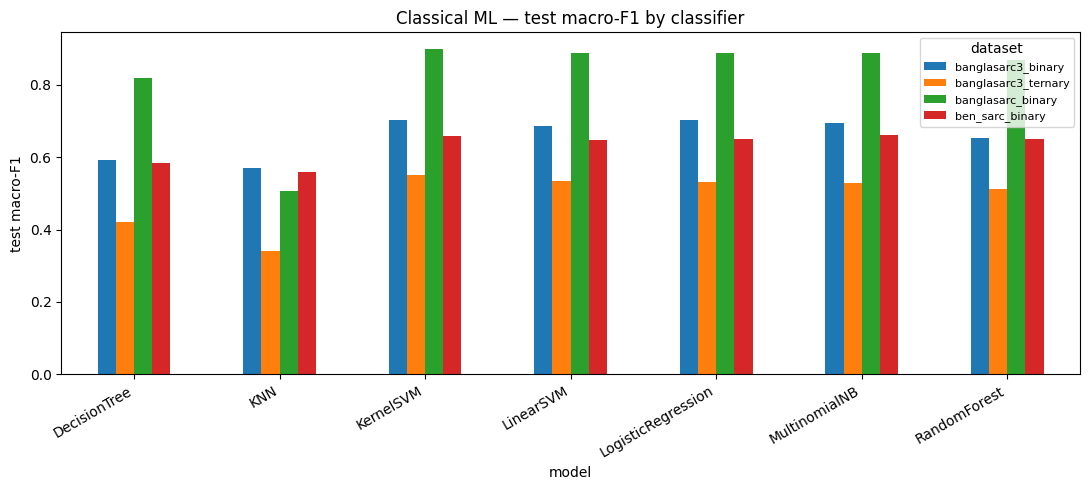


NB02 complete.


In [6]:
# === Best classifier per dataset + summary figure ===
best_per = (results.sort_values("test_macro_f1", ascending=False)
                   .groupby("dataset", as_index=False).first()
                   [["dataset","model","best_ngram","test_macro_f1","test_acc"]])
print("Best classical model per dataset:")
print(best_per.to_string(index=False))

fig, ax = plt.subplots(figsize=(11,5))
results.pivot(index="model", columns="dataset", values="test_macro_f1").plot(kind="bar", ax=ax)
ax.set_ylabel("test macro-F1"); ax.set_title("Classical ML — test macro-F1 by classifier")
ax.legend(title="dataset", fontsize=8); plt.xticks(rotation=30, ha="right")
plt.tight_layout(); plt.savefig(FIGS / "02_classical_ml_macroF1.png", bbox_inches="tight"); plt.show()
print("\nNB02 complete.")